In [2]:
# Imp necessary Libraries (Corrected Version)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np


In [4]:

(x_train, y_train), (x_test, y_test) = cifar10.load_data()


x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2528s 15us/step


In [7]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

TypeError: only length-1 arrays can be converted to Python scalars

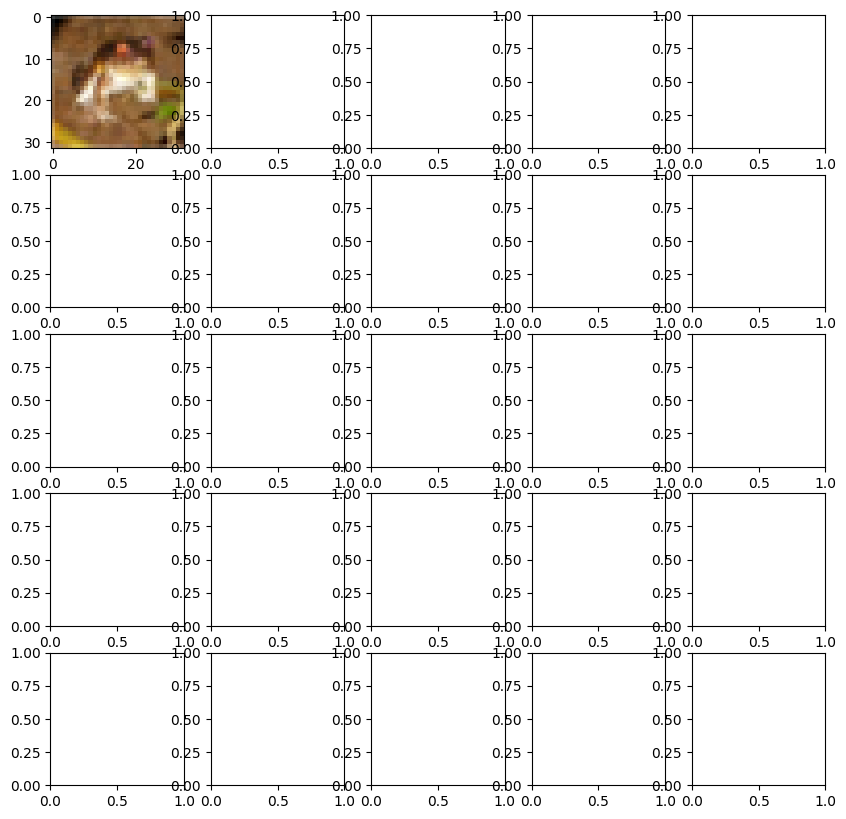

In [8]:
# Define the 10 class labels for CIFAR-10
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))


axes = axes.ravel()


for i in range(25):

    axes[i].imshow(x_train[i])


    label_index = int(y_train[i][0]) if len(y_train.shape) > 2 else int(y_train[i])


    axes[i].set_title(class_names[label_index], fontsize=10)


    axes[i].axis('off')


plt.tight_layout()

plt.show()



In [9]:
# Initialize the sequential container
model = Sequential()


model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)))

model.add(MaxPooling2D(pool_size=(2, 2)))


model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))

model.add(MaxPooling2D(pool_size=(2, 2)))



model.add(Flatten())


model.add(Dense(units=64, activation='relu'))


model.add(Dense(units=10, activation='softmax'))


model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully and is ready for training!")


Model compiled successfully and is ready for training!


In [13]:
import numpy as np


if len(y_train.shape) == 3:
    y_train = np.squeeze(y_train)
    y_test = np.squeeze(y_test)


print("Fixed y_train shape:", y_train.shape)
print("Fixed y_test shape:", y_test.shape)




Fixed y_train shape: (50000, 10, 10)
Fixed y_test shape: (10000, 10, 10)


In [ ]:
# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)

print("\n--- Final Evaluation Metrics ---")
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import cifar10
from keras.utils import to_categorical

print("🔄 Reloading fresh CIFAR-10 datasets...")
# 1. Load clean, unedited labels straight from the source
(_, y_train_clean), (_, y_test_clean) = cifar10.load_data()

# 2. Convert 1D integer labels to 2D one-hot vectors exactly once
y_train = to_categorical(y_train_clean, num_classes=10)
y_test = to_categorical(y_test_clean, num_classes=10)

print("✅ Fresh data loaded!")
print("-> Safe y_train shape:", y_train.shape)  # This will strictly guarantee (50000, 10)
print("-> Safe y_test shape:", y_test.shape)

# 3. Train the model
print("\n🚀 Launching model training...")
history = model.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=10,
    validation_data=(x_test, y_test),
    shuffle=True
)

# 4. Plot the graph
print("\n Bars finished! Rendering plot...")
plt.figure(figsize=(8, 5))
train_acc = history.history.get('accuracy', history.history.get('acc'))
val_acc = history.history.get('val_accuracy', history.history.get('val_acc'))

plt.plot(train_acc, label='Training Accuracy', color='blue', linewidth=2)
plt.plot(val_acc, label='Validation Accuracy', color='orange', linewidth=2)
plt.title('CIFAR-10: Training vs Validation Accuracy over Time', fontsize=14, fontweight='bold')
plt.xlabel('Epochs (Training Loops)', fontsize=12)
plt.ylabel('Accuracy Score (0.0 to 1.0)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right', fontsize=11)
plt.show()





🔄 Reloading fresh CIFAR-10 datasets...
✅ Fresh data loaded!
-> Safe y_train shape: (50000, 10)
-> Safe y_test shape: (10000, 10)

🚀 Launching model training...
Epoch 1/10


ValueError: Creating variables on a non-first call to a function decorated with tf.function.

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
मोडलले अनुमान गरेको क्लास: automobile
वास्तविक (True) क्लास: airplane


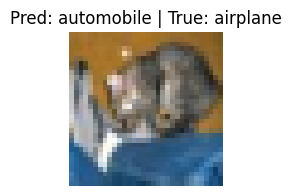

In [15]:

predictions = model.predict(x_test)


predicted_label = np.argmax(predictions[0])
true_label = np.argmax(y_test[0])

print(f"मोडलले अनुमान गरेको क्लास: {class_names[predicted_label]}")
print(f"वास्तविक (True) क्लास: {class_names[true_label]}")


plt.figure(figsize=(2,2))
plt.imshow(x_test[0])
plt.title(f"Pred: {class_names[predicted_label]} | True: {class_names[true_label]}")
plt.axis('off')
plt.show()
